In [1]:
import sys
import os
from pathlib import Path

# Get the project root from the notebook's location
notebook_dir = Path(__file__).parent if '__file__' in dir() else Path.cwd()
# Navigate from notebooks/05_hrp_portfolio_construction up to project root
project_root = notebook_dir.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

os.chdir(project_root)

# Stage 5: Hierarchical Risk Parity Portfolio Construction
This notebook builds a Hierarchical Risk Parity (HRP) portfolio using Stage 3 and Stage 4 outputs. It compares HRP against Equal Weight and Inverse Volatility baselines, and visualizes allocation structure based on cluster hierarchy.

In [2]:
# Load required libraries and HRP utilities
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.clustering.distance_metrics import DistanceMetrics
from src.clustering.hierarchical import compute_linkage_matrix
from src.optimization import (
    EqualWeightAllocator,
    InverseVolatilityAllocator,
    allocate_hrp_weights,
    get_quasi_diagonal_order,
    recursive_bisection,
    compute_cluster_variance,
)

plt.style.use('seaborn-v0_8')

## 1. Load Stage 3 and Stage 4 outputs
This example simulates the expected Stage 3 covariance/correlation output and Stage 4 linkage outputs. In a production pipeline, these would be loaded from persisted Stage 3/4 artifacts.

In [3]:
np.random.seed(7)
dates = pd.date_range(start='2020-01-01', periods=260, freq='B')
returns = pd.DataFrame(
    np.random.randn(len(dates), 6) * 0.015,
    index=dates,
    columns=['Asset A', 'Asset B', 'Asset C', 'Asset D', 'Asset E', 'Asset F'],
)

covariance_matrix = returns.cov()
correlation_matrix = returns.corr()
distance_matrix = DistanceMetrics.correlation_distance(correlation_matrix.values)
distance_df = pd.DataFrame(distance_matrix, index=returns.columns, columns=returns.columns)
linkage_matrix = compute_linkage_matrix(distance_df, method='single')

print('Covariance matrix shape:', covariance_matrix.shape)
print('Linkage matrix shape:', linkage_matrix.shape)

Covariance matrix shape: (6, 6)
Linkage matrix shape: (5, 4)


## 2. Compute HRP weights from linkage and covariance
The HRP algorithm reorders assets using hierarchical clustering, then allocates capital by recursively bisecting the tree and weighting clusters inversely to their variance.

In [4]:
hrp_weights = allocate_hrp_weights(covariance_matrix, linkage_matrix)
ordered_indices = get_quasi_diagonal_order(linkage_matrix)
ordered_assets = [covariance_matrix.index[i] for i in ordered_indices]

hrp_weights.name = 'HRP Weight'
print('Ordered assets for HRP:')
print(pd.Series(ordered_assets, name='Asset Order'))
print('\nHRP weights:')
print(hrp_weights)

Ordered assets for HRP:
0    Asset E
1    Asset F
2    Asset A
3    Asset D
4    Asset B
5    Asset C
Name: Asset Order, dtype: object

HRP weights:
Asset A    0.186064
Asset B    0.142724
Asset C    0.144100
Asset D    0.173013
Asset E    0.189329
Asset F    0.164770
Name: HRP Weight, dtype: float64


In [5]:
# Show recursive allocation steps for interpretation
steps = []
weights = pd.Series(1.0, index=ordered_assets, dtype=float)
clusters = [ordered_assets.copy()]
while clusters:
    cluster = clusters.pop(0)
    if len(cluster) <= 1:
        continue
    split = len(cluster) // 2
    left = cluster[:split]
    right = cluster[split:]
    left_var = compute_cluster_variance(covariance_matrix, left)
    right_var = compute_cluster_variance(covariance_matrix, right)
    left_weight = right_var / (left_var + right_var)
    right_weight = 1.0 - left_weight
    weights[left] *= left_weight
    weights[right] *= right_weight
    steps.append({
        'Cluster': ', '.join(cluster),
        'Left': ', '.join(left),
        'Right': ', '.join(right),
        'Left Variance': left_var,
        'Right Variance': right_var,
        'Left Allocation': left_weight,
        'Right Allocation': right_weight,
    })
    if len(left) > 1:
        clusters.append(left)
    if len(right) > 1:
        clusters.append(right)

allocation_steps_df = pd.DataFrame(steps)
allocation_steps_df

,Cluster,Left,Right,Left Variance,Right Variance,Left Allocation,Right Allocation
0,"Asset E, Asset F, Asset A, Asset D, Asset B, A...","Asset E, Asset F, Asset A","Asset D, Asset B, Asset C",0.000068,0.000080,0.540163,0.459837
1,"Asset E, Asset F, Asset A",Asset E,"Asset F, Asset A",0.000206,0.000111,0.350504,0.649496
2,"Asset D, Asset B, Asset C",Asset D,"Asset B, Asset C",0.000206,0.000125,0.376248,0.623752
3,"Asset F, Asset A",Asset F,Asset A,0.000230,0.000204,0.469654,0.530346
4,"Asset B, Asset C",Asset B,Asset C,0.000225,0.000223,0.497600,0.502400


## 3. Baseline comparisons
Compare HRP to Equal Weight and Inverse Volatility benchmarks.

In [6]:
equal_weights = EqualWeightAllocator().fit(returns).get_weights()
inv_vol_weights = InverseVolatilityAllocator().fit(returns).get_weights()

comparison_df = pd.DataFrame(
    {
        'Equal Weight': equal_weights,
        'Inverse Volatility': inv_vol_weights,
        'HRP': hrp_weights,
    },
    index=returns.columns,
)

comparison_df['HRP'] = comparison_df['HRP'].astype(float)
comparison_df

,Equal Weight,Inverse Volatility,HRP
Asset A,0.166667,0.171405,0.186064
Asset B,0.166667,0.163028,0.142724
Asset C,0.166667,0.163812,0.144100
Asset D,0.166667,0.170193,0.173013
Asset E,0.166667,0.170264,0.189329
Asset F,0.166667,0.161299,0.164770


## 4. Visualizations
We present the final portfolio weights, the HRP cluster allocations, and a comparison across the three methods.

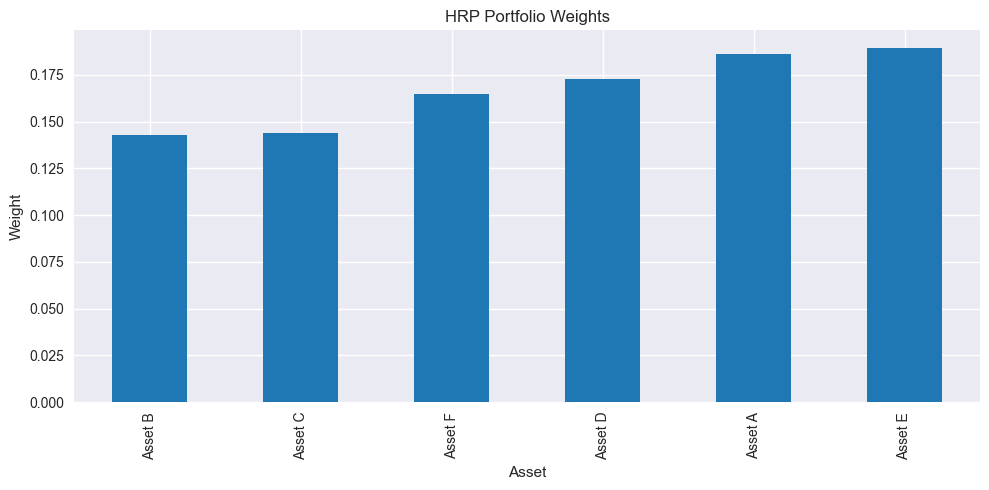

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df['HRP'].sort_values().plot(kind='bar', ax=ax, color='tab:blue')
ax.set_title('HRP Portfolio Weights')
ax.set_ylabel('Weight')
ax.set_xlabel('Asset')
plt.tight_layout()
plt.show()

In [8]:
cluster_allocations = allocation_steps_df[['Left', 'Right', 'Left Allocation', 'Right Allocation']].copy()
cluster_allocations

,Left,Right,Left Allocation,Right Allocation
0,"Asset E, Asset F, Asset A","Asset D, Asset B, Asset C",0.540163,0.459837
1,Asset E,"Asset F, Asset A",0.350504,0.649496
2,Asset D,"Asset B, Asset C",0.376248,0.623752
3,Asset F,Asset A,0.469654,0.530346
4,Asset B,Asset C,0.497600,0.502400


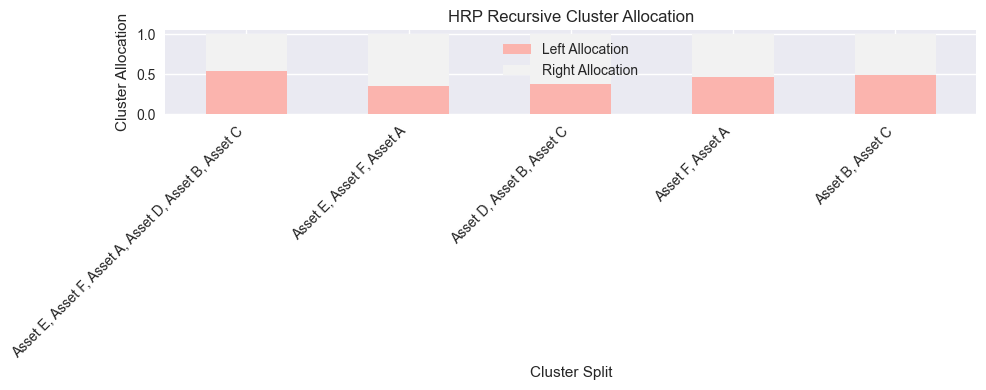

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
allocation_steps_df.set_index('Cluster')[['Left Allocation', 'Right Allocation']].plot(
    kind='bar', stacked=True, ax=ax, colormap='Pastel1'
)
ax.set_title('HRP Recursive Cluster Allocation')
ax.set_ylabel('Cluster Allocation')
ax.set_xlabel('Cluster Split')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

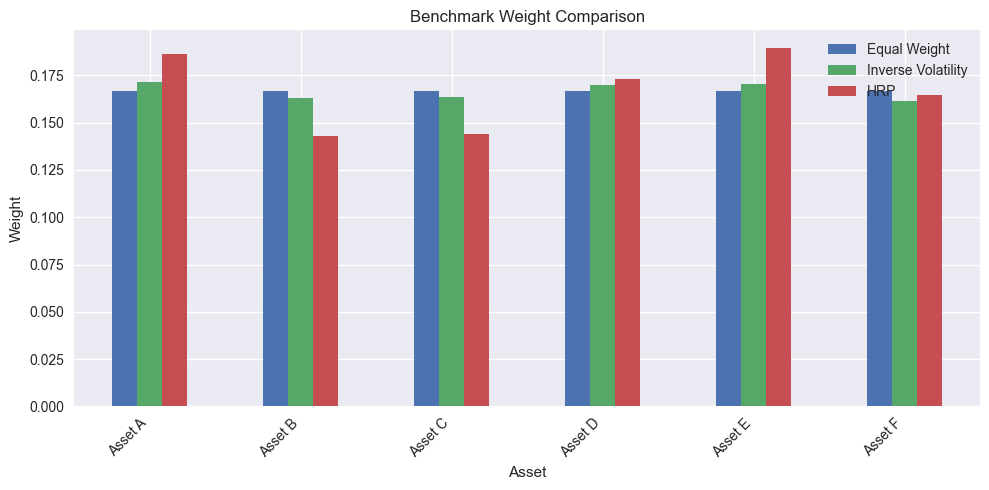

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
comparison_df.plot(kind='bar', ax=ax)
ax.set_title('Benchmark Weight Comparison')
ax.set_ylabel('Weight')
ax.set_xlabel('Asset')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Interpretation
- Recursive bisection splits the asset tree into clusters and allocates capital to risk-balanced branches.
- HRP is risk-based and uses the covariance structure instead of relying on return forecasts.
- Clustering improves robustness by grouping similar assets, reducing concentration in closely correlated exposures.
- Equal Weight treats all assets identically.
- Inverse Volatility allocates by individual asset risk.
- HRP allocates by cluster risk, adjusting for hierarchy and covariance structure.

### Advantages and limitations
- Advantages: robust to estimation noise, adaptive to correlation structure, avoids over-concentration.
- Limitations: relies on clustering quality, can still overweight illiquid or heavily correlated groups if the linkage tree is poorly chosen.